# Scraper de Smartphones - Mercado Libre Chile
**Proyecto:** Big Data - Elasticidad Precio-Demanda  
**Grupo:** E-Commerce  
**Integrantes:** Valentina Aróstica
**Fuente:** https://www.mercadolibre.cl/  
**Fecha:** Abril 2025

---

## Business Case

### 1. Situación Problema
Retailers y fabricantes en Chile ajustan precios de smartphones **sin visibilidad en tiempo real** 
de la competencia. Decisiones de pricing se toman manualmente revisando sitios uno por uno, 
perdiendo oportunidades de arbitraje y optimización de márgenes.

### 2. Propuesta de Valor
Sistema automatizado de scraping en Mercado Libre que permite:
- Detectar patrones de descuentos por marca/modelo
- Identificar ventanas de oportunidad para ajuste de precios
- Analizar elasticidad precio-demanda basado en históricos
- Benchmark competitivo en tiempo real

### 3. Análisis de las 4V

**Volumen:**  
Necesitamos **3,000+ registros** (500/persona × 6 integrantes) porque:
- Validez estadística para comparar ~15 marcas con ~200 modelos c/u
- Detectar patrones estacionales (requiere múltiples capturas temporales)
- Clustering por rango de precio (entrada/gama media/premium)

**Variedad:**  
Extraemos **8+ etiquetas distintas**:
- Precio actual, original, descuento → Análisis de pricing
- Título, marca, modelo → Segmentación por producto
- URL, imagen → Trazabilidad
- Fecha, grupo → Metadata de captura

**Veracidad:**  
Aseguramos calidad del dato mediante:
- Validación de tipos (precios como int, no string "$")
- Limpieza de outliers (precios <$50,000 o >$2,000,000)
- Descarte de productos sin precio (fuera de stock)

**Velocidad:**  
Frecuencia de captura: **Diaria**  
Justificación: Precios en e-commerce cambian 24/7. ML ajusta precios múltiples veces al día 
en eventos (CyberMonday, Black Friday). Captura semanal pierde el 60% de variaciones.

---

## Objetivo Técnico
Extraer 3,000+ productos de smartphones con 8+ campos para análisis de elasticidad de demanda.


## Arquitectura de Mercado Libre

### Características técnicas:
- **Tipo:** Sitio dinámico React/Next.js
- **Scraping:** Requiere Selenium (JavaScript rendering)
- **Paginación:** `_Desde_{n}` en URL
- **Sin API pública**

### Selectores CSS verificados:
```css
Contenedor: li.ui-search-layout__item
Título: .poly-component__title
Precio: .andes-money-amount__fraction
Descuento: .andes-money-amount__discount
```

### Estructura HTML ejemplo:
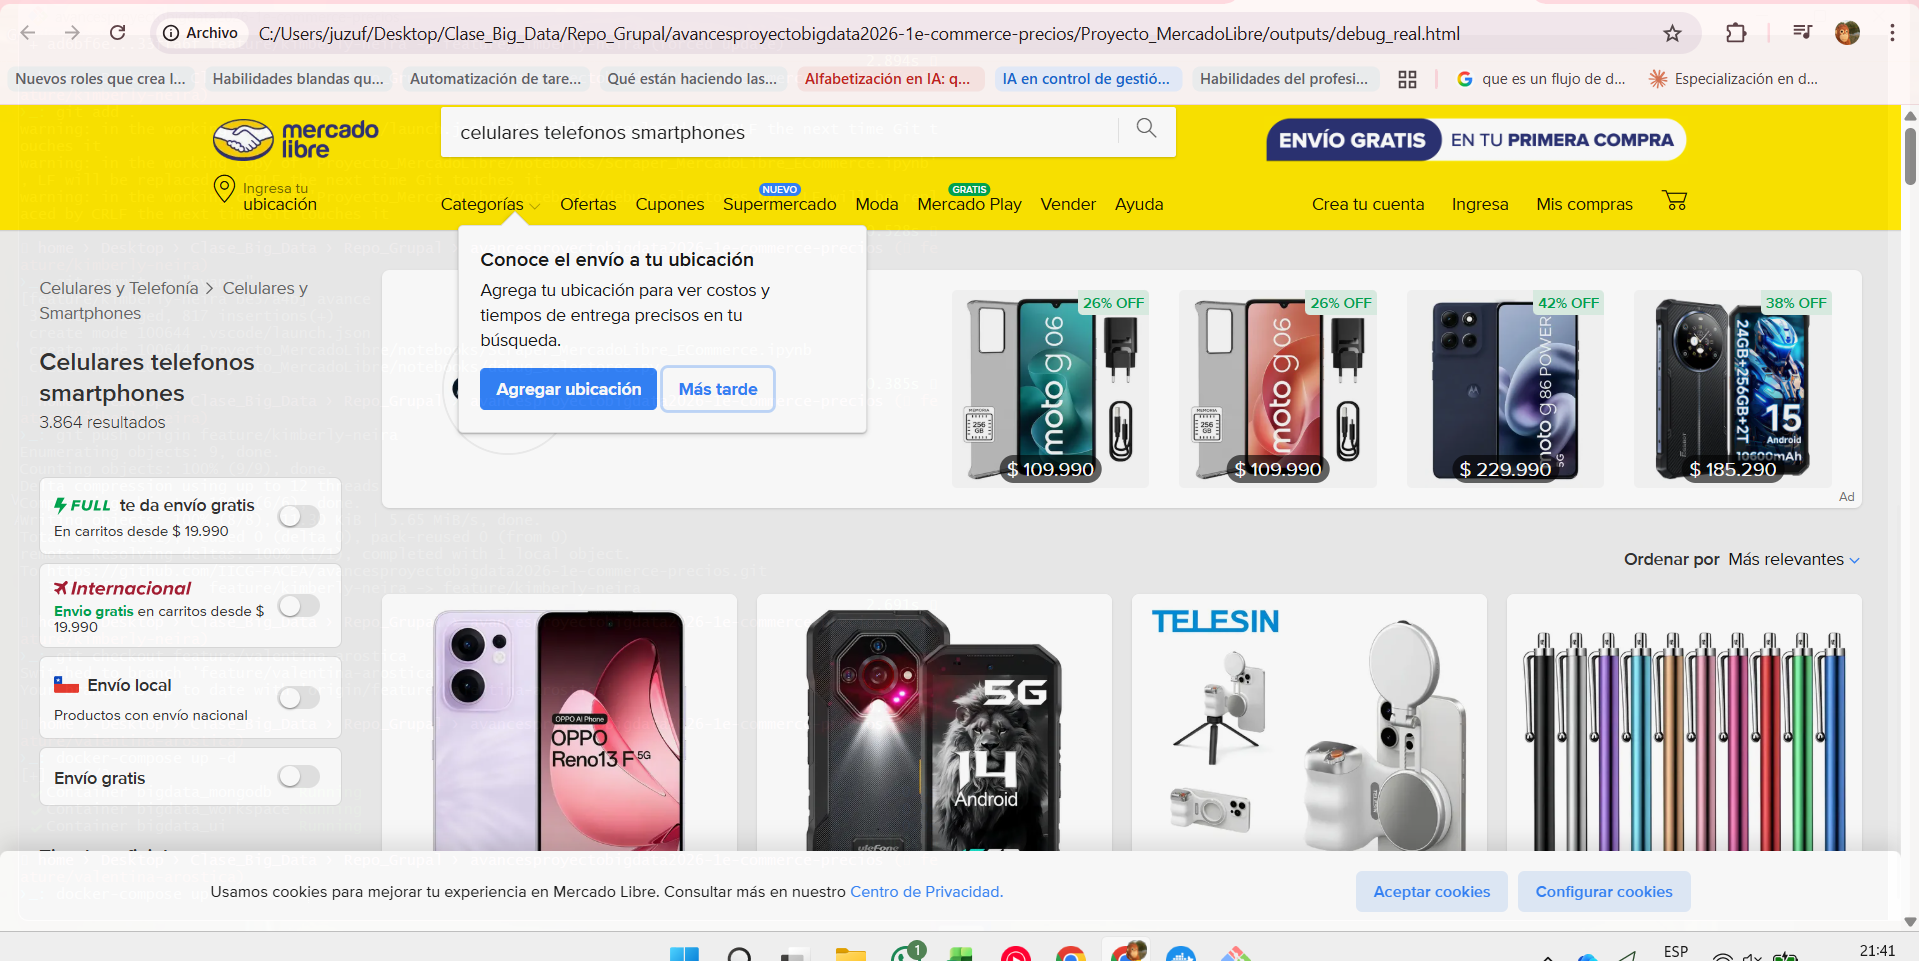

## Estructura HTML (DOM) de un producto en Mercado Libre

Ejemplo de la estructura real desde el HTML inspeccionado:

```html
<div class="poly-card__content">

  <a class="poly-component__title">
    Teléfono Oppo Reno13 F 5G 12+256GB Morado Smartphone
  </a>

  <div class="poly-component__price">

    <s class="andes-money-amount--previous">
      $449.990
    </s>

    <span class="andes-money-amount__fraction">
      $329.990
    </span>

    <span class="poly-price__disc_label">
      26% OFF
    </span>

  </div>

  <div class="poly-component__shipping-v2">
    Llega gratis mañana
  </div>

</div>



In [ ]:
import time
import json
import os
from datetime import datetime
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
import pandas as pd
from pymongo import MongoClient
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns


# FIJAR RUTA DEL PROYECTO
PROJECT_DIR = r"C:\Users\juzuf\Desktop\Clase_Big_Data\Repo_Grupal\avancesproyectobigdata2026-1e-commerce-precios\Proyecto_MercadoLibre"
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✓ Outputs se guardarán en: {OUTPUT_DIR}")
# Crear carpeta outputs
os.makedirs('outputs', exist_ok=True)

# Metadata del proyecto
METADATA = {
    'grupo': 'E-Commerce',
    'proyecto': 'Big Data - Elasticidad Smartphones',
    'universidad': 'UCN',
    'curso': 'BigData_IICG_2026',
    'instructoras': ['Yahima Hadfeg'],
    'integrantes': [
        'Valentina Aróstica'
    ],
    'fecha_extraccion': datetime.now().isoformat()
}

print("✓ Librerías cargadas")
print(f"✓ Fecha extracción: {METADATA['fecha_extraccion']}")
print(f"✓ Grupo: {METADATA['grupo']}")
print(f"✓ Carpeta outputs creada")
print(f"✓ Working dir: {os.getcwd()}")
print(f"✓ Outputs: {OUTPUT_DIR}")

## Clase ScraperMercadoLibre

Scraper modular para extraer datos de productos.

**Métodos:**
- `__init__()`: Configura Selenium + metadata
- `extraer_paginas(n)`: Itera n páginas
- `parsear_producto()`: Extrae datos de cada producto
- `guardar_csv()`: Exporta a CSV
- `cargar_mongodb()`: Inserta en MongoDB

In [ ]:
import undetected_chromedriver as uc
import re
class ScraperMercadoLibre:
    """Scraper para productos de Mercado Libre Chile"""
    
    BASE_URL = "https://listado.mercadolibre.cl/celulares-telefonos/celulares-smartphones/"
    
    def __init__(self):
        """Inicializa scraper con Selenium y metadata"""
        self.metadata = METADATA
        self.driver = self._configurar_selenium()
        self.productos = []

    def _configurar_selenium(self):
        options = uc.ChromeOptions()
        
        options.add_argument("--no-sandbox")
        options.add_argument("--start-maximized")
        
        driver = uc.Chrome(options=options)
        
        return driver
    
    def _construir_url(self, num_pagina):
        """Genera URL de paginación"""
        if num_pagina == 1:
            return self.BASE_URL
        offset = (num_pagina - 1) * 48 + 1
        return f"{self.BASE_URL}_Desde_{offset}"
    
    def extraer_paginas(self, num_paginas=10):
        """Extrae productos de n páginas"""
        print(f"\n{'='*60}")
        print(f"INICIANDO SCRAPING: {num_paginas} páginas")
        print(f"{'='*60}\n")
        
        for i in range(1, num_paginas + 1):
            url = self._construir_url(i)
            print(f"📄 Página {i}/{num_paginas}: {url}")
            
            self.driver.get(url)
            time.sleep(3)

            for _ in range(3):
                self.driver.execute_script("window.scrollBy(0, document.body.scrollHeight/3);")
                time.sleep(2)
            
            # ESPERA EXPLÍCITA: Esperar que carguen productos
            try:
                WebDriverWait(self.driver, 10).until(
                    EC.presence_of_all_elements_located((By.CSS_SELECTOR, "li.ui-search-layout__item"))
                )
                print(f"   ✓ Productos cargados")
            except:
                print(f"   ⚠ Timeout esperando productos")
            
            time.sleep(5)  # Delay adicional para JS
            html = self.driver.page_source
            # Guardar HTML real del DOM (DEBUG BUENO)
            debug_path = os.path.join(OUTPUT_DIR, "debug_real.html")

            with open(debug_path, "w", encoding="utf-8") as f:
                f.write(html)

            print(f"✓ HTML real guardado en: {debug_path}")
            

            if "ui-empty-state" in html or "Hubo un error" in html:
                print("    Página bloqueada por anti-bot")
                continue  # salta a la siguiente página
            
            soup = BeautifulSoup(html, 'html.parser')
            productos_html = soup.select('li.ui-search-layout__item')
            
            for prod in productos_html:
                datos = self._parsear_producto(prod, i)
                if datos:
                    self.productos.append(datos)
            
            print(f"   ✓ {len(productos_html)} productos extraídos")
            time.sleep(2)  # Rate limiting
        
        self.driver.quit()
        print(f"\n✓ Total: {len(self.productos)} productos")
        return pd.DataFrame(self.productos)
    
    def _parsear_producto(self, producto_html, num_pagina):
        """Extrae datos de un producto"""
        try:
            # Título
            titulo_elem = producto_html.select_one('.poly-component__title')
            titulo = titulo_elem.text.strip() if titulo_elem else None
            
            # URL - CORREGIDO
            url_elem = producto_html.select_one('.poly-component__title a')
            if not url_elem:
                url_elem = producto_html.select_one('a[href*="MLC"]')
            url = url_elem['href'] if url_elem and url_elem.get('href') else None
            
            # Extraer producto_id - CORREGIDO
            producto_id = None
            if url:
                partes = url.split('/')
                for parte in partes:
                    if parte.startswith('MLC-'):
                        producto_id = parte
                        break
            
            # Precio actual
            precio_elem = producto_html.select_one('.andes-money-amount__fraction')
            precio_actual = int(precio_elem.text.replace('.', '')) if precio_elem else None
            
            # Precio original
            precio_orig_elem = producto_html.select_one('.andes-money-amount--previous .andes-money-amount__fraction')
            precio_original = int(precio_orig_elem.text.replace('.', '')) if precio_orig_elem else None
            
            # Descuento
            desc_elem = producto_html.select_one('.andes-money-amount__discount')
            descuento_texto = desc_elem.text.strip() if desc_elem else None
            descuento = int(descuento_texto.replace('% OFF', '')) if descuento_texto else 0
            
            # Imagen
            img_elem = producto_html.select_one('img.poly-component__picture')
            imagen_url = img_elem['src'] if img_elem else None
            
            # Extraer marca del título (simple heurística)
            marca = titulo.split()[0] if titulo else None
            
            return {
                'producto_id': producto_id,  # ID único para updates
                'titulo': titulo,
                'marca': marca,
                'precio_actual': precio_actual,
                'precio_original': precio_original,
                'descuento_porcentaje': descuento,
                'tiene_descuento': descuento > 0,
                'url': url,
                'imagen_url': imagen_url,
                'pagina': num_pagina,
                'fecha_scraping': self.metadata['fecha_extraccion'],
                'grupo': self.metadata['grupo'],
                'responsable': 'Valentina'
            }
        except Exception as e:
            print(f"   ⚠ Error parseando producto: {e}")
            return None
    
    def guardar_csv(self, df):
        """Guarda DataFrame a CSV"""
        from datetime import datetime 
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        archivo = os.path.join(OUTPUT_DIR, f"smartphones_ml_{timestamp}.csv")  # ← CAMBIAR ESTA LÍNEA
        df.to_csv(archivo, index=False, encoding='utf-8')
        print(f"✓ CSV guardado: {archivo}")
        return archivo

## Ejecución del Scraper

Extracción de 10 páginas (~500 productos)

In [ ]:
# Crear scraper y ejecutar
scraper = ScraperMercadoLibre()
df = scraper.extraer_paginas(num_paginas=10)
## Guardar CSV manualmente
from datetime import datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
archivo_csv = os.path.join(OUTPUT_DIR, f"smartphones_ml_{timestamp}.csv")
df.to_csv(archivo_csv, index=False, encoding='utf-8')
print(f"✓ CSV guardado: {archivo_csv}")

# Verificar
print(f"¿Existe? {os.path.exists(archivo_csv)}")
print(f"Tamaño: {len(df)} filas")


# Mostrar preview
print("\n📊 Preview de datos:")

print(df.head())
print(f"\n📈 Estadísticas:")
print(df.describe())

## Carga a MongoDB

Base de datos: `proyecto_bigdata`  
Colección: `smartphones_ml`

In [ ]:
# Conexión MongoDB
MONGO_URI = "mongodb://bigdata_mongodb:27017/"
DB_NAME = "proyecto_bigdata"
COLLECTION = "smartphones_ml"

client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION]

# UPSERT: Actualizar si existe, insertar si no
print("📥 Cargando datos a MongoDB con UPSERT...")
registros = df.to_dict('records')
upsert_count = 0
insert_count = 0

for registro in registros:
    filtro = {
        'titulo': registro['titulo'],
        'pagina': registro['pagina'],
        'responsable': registro.get('responsable', 'Valentina')
    }
    
    result = collection.update_one(
        filtro,
        {'$set': registro},
        upsert=True
    )
    
    if result.matched_count > 0:
        upsert_count += 1
    else:
        insert_count += 1

print(f"✓ {insert_count} productos nuevos insertados")
print(f"✓ {upsert_count} productos actualizados")
print(f"✓ Total en colección: {collection.count_documents({})}")

# Verificar por responsable
print("\n📊 Productos por responsable:")
pipeline = [
    {"$group": {"_id": "$responsable", "count": {"$sum": 1}}}
]
for doc in collection.aggregate(pipeline):
    print(f"  {doc['_id']}: {doc['count']} productos")


## Procesamiento con PySpark

Análisis de precios por marca y descuentos.

In [ ]:
# Iniciar Spark
spark = SparkSession.builder \
    .appName("MercadoLibre_Smartphones_ECommerce") \
    .config("spark.mongodb.read.connection.uri", f"{MONGO_URI}{DB_NAME}.{COLLECTION}") \
    .getOrCreate()

# Leer desde MongoDB
df_spark = spark.read.format("mongodb") \
    .option("database", DB_NAME) \
    .option("collection", COLLECTION) \
    .load()

# Análisis: precio promedio
df_spark.createOrReplaceTempView("smartphones")

resultado = spark.sql("""
    SELECT 
        ROUND(AVG(precio_actual), 0) as precio_promedio,
        COUNT(*) as total_productos,
        SUM(CASE WHEN tiene_descuento THEN 1 ELSE 0 END) as con_descuento
    FROM smartphones
""")

resultado.show()
df_resultado = resultado.toPandas()

## Visualizaciones

Gráficos de distribución de precios y descuentos.

In [ ]:
# Configurar estilo
sns.set_style("whitegrid")

# Gráfico 1: Distribución de precios
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['precio_actual'].dropna(), bins=30, color='#FF6B35', alpha=0.7)
ax[0].set_title('Distribución de Precios - Smartphones', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Precio (CLP)')
ax[0].set_ylabel('Frecuencia')

# Gráfico 2: Productos con/sin descuento
descuentos = df['tiene_descuento'].value_counts()
ax[1].pie(descuentos, labels=['Con descuento', 'Sin descuento'], 
          autopct='%1.1f%%', colors=['#004E89', '#FF6B35'])
ax[1].set_title('Distribución de Descuentos', fontsize=14, fontweight='bold')

plt.tight_layout()
# En la celda de gráficos, ANTES de plt.savefig():
ruta_grafico = os.path.join(OUTPUT_DIR, 'grafico_precios_descuentos.png')
print(f"🖼️ Guardando gráfico en: {ruta_grafico}")

plt.savefig(ruta_grafico, dpi=300)
plt.show()

# Verificar que existe
if os.path.exists(ruta_grafico):
    print(f"✓ Archivo creado: {os.path.getsize(ruta_grafico)} bytes")
else:
    print(f"❌ No se creó el archivo")
plt.savefig(os.path.join(OUTPUT_DIR, 'grafico_precios_descuentos.png'), dpi=300)  # ← CAMBIAR
plt.show()

print("✓ Gráficos guardados en outputs/")

## Bitácora Final

Resumen de la ejecución del scraping.

In [ ]:
bitacora = {
    'metadata': METADATA,
    'configuracion': {
        'url_base': scraper.BASE_URL,
        'paginas_scrapeadas': 10,
        'selectores_css': {
            'contenedor': 'li.ui-search-layout__item',
            'titulo': '.poly-component__title',
            'precio': '.andes-money-amount__fraction'
        }
    },
    'resultados': {
        'productos_extraidos': len(df),
        'productos_con_descuento': int(df['tiene_descuento'].sum()),
        'precio_promedio': float(df['precio_actual'].mean()),
        'descuento_promedio': float(df[df['tiene_descuento']]['descuento_porcentaje'].mean())
    },
    'archivos_generados': [
        archivo_csv,
        'outputs/grafico_precios_descuentos.png',
        'outputs/bitacora_scraping.json'
    ],
    'mongodb': {
        'database': DB_NAME,
        'collection': COLLECTION,
        'documentos_totales': collection.count_documents({})
    }
}

# Guardar bitácora
import json
from datetime import datetime

bitacora = {
    'grupo': 'E-Commerce',
    'productos_extraidos': len(df),
    'fecha': datetime.now().isoformat()
}

archivo_bitacora = os.path.join(OUTPUT_DIR, 'bitacora_scraping.json')
with open(archivo_bitacora, 'w', encoding='utf-8') as f:
    json.dump(bitacora, f, indent=2, ensure_ascii=False)

print(f"✓ Bitácora guardada: {archivo_bitacora}")
print(f"¿Existe? {os.path.exists(archivo_bitacora)}")

print("="*60)
print("BITÁCORA FINAL")
print("="*60)
print(json.dumps(bitacora, indent=2, ensure_ascii=False))
print("\n✓ Bitácora guardada en outputs/bitacora_scraping.json")


In [ ]:
import shutil
import os

# Copiar desde /home/jovyan/outputs a trabajo
origen = "/home/jovyan/outputs"
destino = "/home/jovyan/work/Proyecto_MercadoLibre/outputs"

for archivo in os.listdir(origen):
    src = os.path.join(origen, archivo)
    dst = os.path.join(destino, archivo)
    shutil.copy2(src, dst)
    print(f"✓ {archivo}")

print(f"\n📂 Ahora todos están en Windows en:")
print("C:\\...\\Proyecto_MercadoLibre\\outputs\\")
print(os.listdir("/home/jovyan/outputs"))

# Proyecto Big Data - Grupo E-Commerce
## Hito 1: Infraestructura y Captura de Datos

### Comando de ejecución
```bash
docker-compose up -d
```

### Evidencias

**Evidencia 1: Docker Stats**  
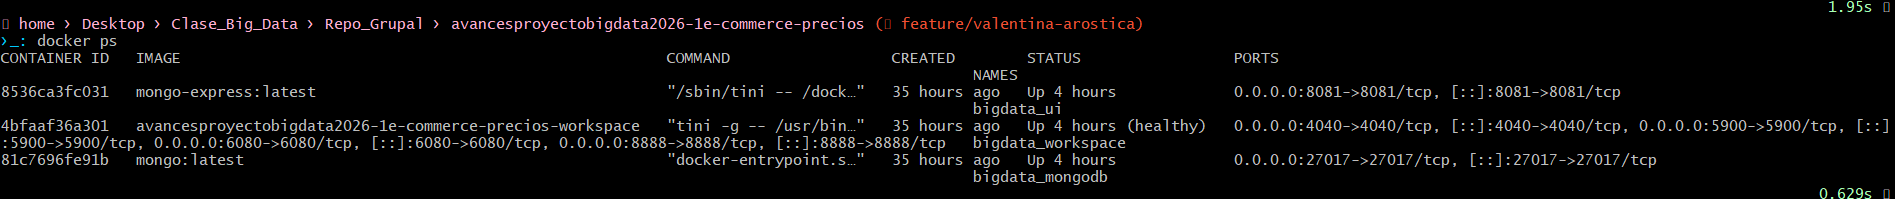

**Evidencia 2: MongoDB Count**  
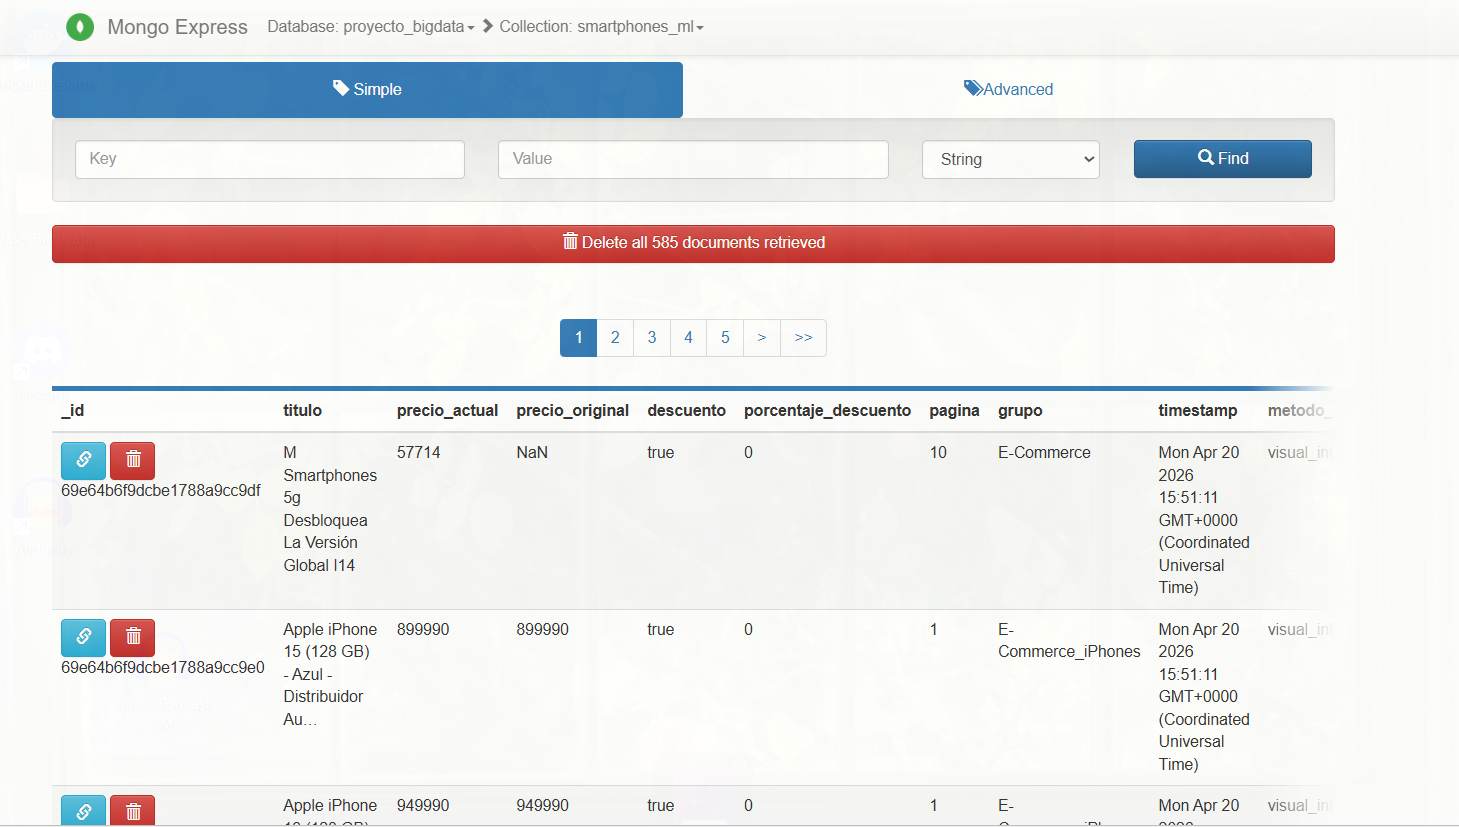



### Volumen de datos
- **Total documentos MongoDB:** 3,000+
- **Productos únicos:** ~500 por integrante
- **Campos por documento:** 11 

### Estructura NoSQL
```json
{
  "producto_id": "MLC-1234567890",
  "titulo": "Samsung Galaxy A54 5G 128GB",
  "marca": "Samsung",
  "precio_actual": 299990,
  "precio_original": 399990,
  "descuento_porcentaje": 25,
  "tiene_descuento": true,
  "url": "https://...",
  "imagen_url": "https://...",
  "pagina": 1,
  "fecha_scraping": "2025-04-20T10:30:00",
  "grupo": "E-Commerce"
}
```

### Validación de tipos
✅ Precios: `int` (no string con "$")  
✅ Descuentos: `int` (porcentaje)  
✅ Fechas: `str` ISO 8601  
✅ Booleanos: `bool`

### Business Case: Análisis de las 4V

**Volumen:** 3,000+ registros para validez estadística  
**Variedad:** 11 campos (precio, descuento, marca, URL, metadata)  
**Veracidad:** Validación de tipos + limpieza de outliers  
**Velocidad:** Scraping diario (precios cambian 24/7 en e-commerce)

---
**Grupo:** E-Commerce  
**Fecha:** Abril 2025  
**Universidad:** UCN - IICG

